# Judge Reliability Analysis
**Analyses:** A1 (Krippendorff's Alpha) | A2 (Cohen's Kappa) | A3 (Self-Eval Bias)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# CHANGE THIS PATH TO YOUR scores.csv LOCATION
df = pd.read_csv('scores.csv', sep=';', encoding='utf-8-sig')
print(f"✓ Loaded {len(df)} outputs")

✓ Loaded 600 outputs


In [3]:
judges_acc = ['Hum', 'Per', 'GPT', 'Gemini', 'Cla']
judges_rea_gra = ['Hum', 'Per', 'GPT', 'Gem', 'Cla']
rubrics = ['Acc', 'Rea', 'Gra']
rubric_names = {'Acc': 'Accuracy', 'Rea': 'Reasoning', 'Gra': 'Grammar'}
judge_names = {'Hum': 'Human', 'Per': 'Perplexity', 'GPT': 'GPT-4o', 'Gemini': 'Gemini-2.0', 'Gem': 'Gemini-2.0', 'Cla': 'Claude-3.5'}
print("✓ Setup complete")

✓ Setup complete


In [4]:
def krippendorff_alpha(data):
    data = data[:, ~np.all(np.isnan(data), axis=0)]
    n_judges, n_items = data.shape
    values = np.sort(np.unique(data[~np.isnan(data)]))
    n_values = len(values)
    value_to_idx = {v: i for i, v in enumerate(values)}
    coincidence_matrix = np.zeros((n_values, n_values))
    for item_idx in range(n_items):
        item_ratings = data[:, item_idx]
        item_ratings = item_ratings[~np.isnan(item_ratings)]
        if len(item_ratings) < 2:
            continue
        m = len(item_ratings)
        for c, k in combinations(item_ratings, 2):
            c_idx, k_idx = value_to_idx[c], value_to_idx[k]
            weight = 1.0 / (m - 1)
            coincidence_matrix[c_idx, k_idx] += weight
            coincidence_matrix[k_idx, c_idx] += weight
    n_c = coincidence_matrix.sum(axis=1)
    n_total = n_c.sum()
    delta = np.zeros((n_values, n_values))
    for c in range(n_values):
        for k in range(n_values):
            delta[c, k] = (values[c] - values[k]) ** 2
    D_o = sum(coincidence_matrix[c, k] * delta[c, k] for c in range(n_values) for k in range(n_values)) / n_total
    D_e = sum(n_c[c] * n_c[k] * delta[c, k] for c in range(n_values) for k in range(n_values)) / (n_total * (n_total - 1))
    return 1.0 if D_e == 0 else 1 - (D_o / D_e)

print("✓ Function defined")

✓ Function defined


In [5]:
print("A1. OVERALL JUDGE AGREEMENT")
print("="*50)
alpha_results = {}
for rubric in rubrics:
    judge_list = judges_acc if rubric == 'Acc' else judges_rea_gra
    judge_columns = [f"{rubric}_{judge}" for judge in judge_list]
    data_matrix = df[judge_columns].T.values
    alpha = krippendorff_alpha(data_matrix)
    alpha_results[rubric] = alpha
    interpretation = "Excellent" if alpha >= 0.800 else "Good" if alpha >= 0.667 else "Poor"
    print(f"{rubric_names[rubric]:12} α = {alpha:.4f}  ({interpretation})")

A1. OVERALL JUDGE AGREEMENT
Accuracy     α = 0.9151  (Excellent)
Reasoning    α = 0.8830  (Excellent)
Grammar      α = 0.2416  (Poor)


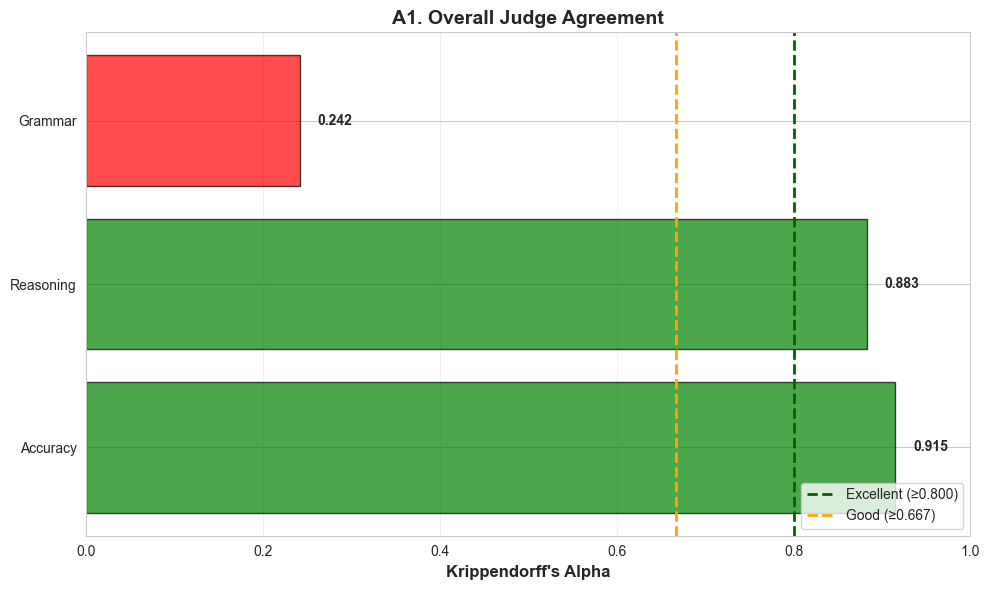

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
rubric_labels = [rubric_names[r] for r in rubrics]
alpha_values = [alpha_results[r] for r in rubrics]
colors = ['green' if a >= 0.8 else 'orange' if a >= 0.667 else 'red' for a in alpha_values]
bars = ax.barh(rubric_labels, alpha_values, color=colors, alpha=0.7, edgecolor='black')
ax.axvline(x=0.8, color='darkgreen', linestyle='--', linewidth=2, label='Excellent (≥0.800)')
ax.axvline(x=0.667, color='orange', linestyle='--', linewidth=2, label='Good (≥0.667)')
for i, (bar, val) in enumerate(zip(bars, alpha_values)):
    ax.text(val + 0.02, i, f'{val:.3f}', va='center', fontweight='bold')
ax.set_xlabel("Krippendorff's Alpha", fontsize=12, fontweight='bold')
ax.set_title("A1. Overall Judge Agreement", fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
print("\nA2. HUMAN-JUDGE ALIGNMENT")
print("="*50)
kappa_results = {}
best_judges = {}
for rubric in rubrics:
    print(f"\n{rubric_names[rubric]}:")
    judge_list = judges_acc if rubric == 'Acc' else judges_rea_gra
    human_col = f"{rubric}_Hum"
    human_scores = df[human_col].values
    kappas = {}
    for judge in judge_list:
        if judge == 'Hum':
            continue
        judge_col = f"{rubric}_{judge}"
        judge_scores = df[judge_col].values
        kappa = cohen_kappa_score(human_scores, judge_scores, weights='quadratic')
        kappas[judge] = kappa
        judge_name = judge_names.get(judge, judge)
        interpretation = "Strong" if kappa >= 0.8 else "Moderate" if kappa >= 0.6 else "Fair"
        print(f"  {judge_name:15} κ = {kappa:.4f}  ({interpretation})")
    kappa_results[rubric] = kappas
    best_judges[rubric] = max(kappas.items(), key=lambda x: x[1])[0]


A2. HUMAN-JUDGE ALIGNMENT

Accuracy:
  Perplexity      κ = 0.8957  (Strong)
  GPT-4o          κ = 0.8838  (Strong)
  Gemini-2.0      κ = 0.9175  (Strong)
  Claude-3.5      κ = 0.8926  (Strong)

Reasoning:
  Perplexity      κ = 0.8759  (Strong)
  GPT-4o          κ = 0.8698  (Strong)
  Gemini-2.0      κ = 0.8931  (Strong)
  Claude-3.5      κ = 0.8846  (Strong)

Grammar:
  Perplexity      κ = 0.5326  (Fair)
  GPT-4o          κ = 0.4232  (Fair)
  Gemini-2.0      κ = 0.1007  (Fair)
  Claude-3.5      κ = 0.3615  (Fair)


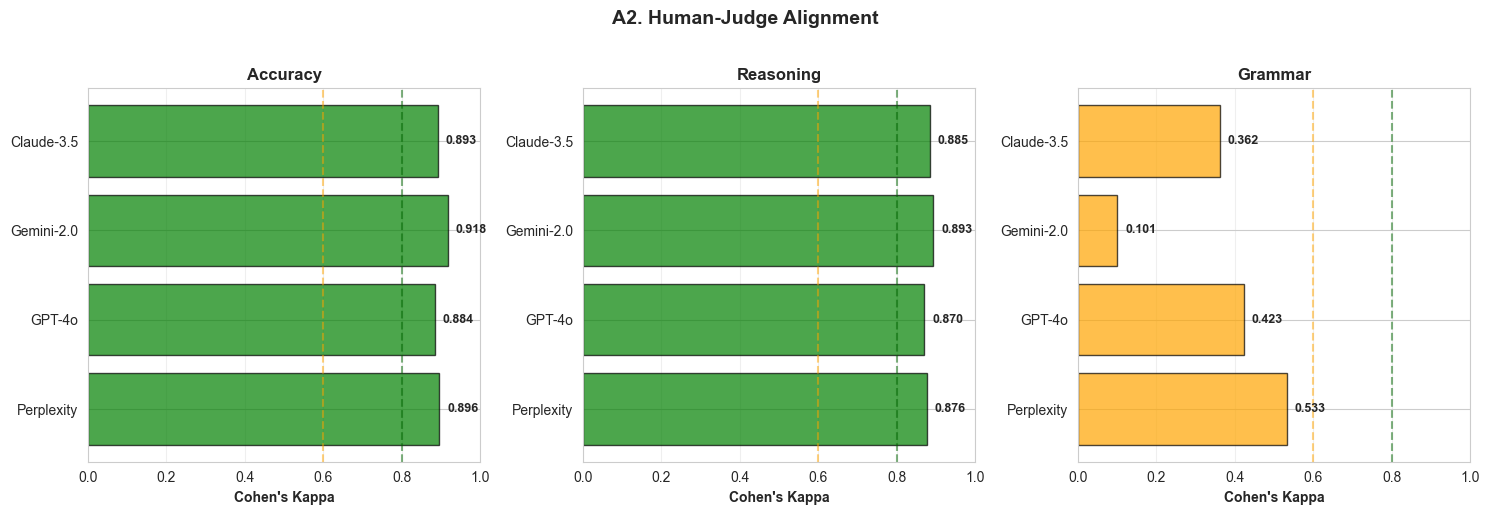

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, rubric in enumerate(rubrics):
    ax = axes[idx]
    judge_list = [j for j in (judges_acc if rubric == 'Acc' else judges_rea_gra) if j != 'Hum']
    judge_labels = [judge_names.get(j, j) for j in judge_list]
    kappa_values = [kappa_results[rubric][j] for j in judge_list]
    colors = ['green' if k >= 0.8 else 'gold' if k >= 0.6 else 'orange' for k in kappa_values]
    bars = ax.barh(judge_labels, kappa_values, color=colors, alpha=0.7, edgecolor='black')
    for i, (bar, val) in enumerate(zip(bars, kappa_values)):
        ax.text(val + 0.02, i, f'{val:.3f}', va='center', fontweight='bold', fontsize=9)
    ax.axvline(x=0.8, color='darkgreen', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axvline(x=0.6, color='orange', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.set_xlabel("Cohen's Kappa", fontsize=10, fontweight='bold')
    ax.set_title(rubric_names[rubric], fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.0)
    ax.grid(axis='x', alpha=0.3)
fig.suptitle("A2. Human-Judge Alignment", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
print("\nA3. SELF-EVALUATION BIAS")
print("="*50)
judge_to_model = {'GPT': 'GPT', 'Gemini': 'Gemini', 'Gem': 'Gemini', 'Cla': 'Claude'}
bias_results = {}
for rubric in rubrics:
    print(f"\n{rubric_names[rubric]}:")
    judge_list = judges_acc if rubric == 'Acc' else judges_rea_gra
    results = []
    for judge in judge_list:
        if judge in ['Hum', 'Per']:
            continue
        judge_model = judge_to_model.get(judge)
        if not judge_model:
            continue
        judge_col = f"{rubric}_{judge}"
        own_scores = df.loc[df['Model'] == judge_model, judge_col]
        others_scores = df.loc[df['Model'] != judge_model, judge_col]
        bias = own_scores.mean() - others_scores.mean()
        t_stat, p_value = stats.ttest_ind(own_scores, others_scores)
        sig = "✓" if p_value < 0.05 else ""
        print(f"  {judge_names[judge]:15} Bias={bias:+.3f}  p={p_value:.4f} {sig}")
        results.append({'Judge': judge_names[judge], 'Bias': bias, 'P_Value': p_value, 'Significant': p_value < 0.05})
    bias_results[rubric] = pd.DataFrame(results)


A3. SELF-EVALUATION BIAS

Accuracy:
  GPT-4o          Bias=-0.433  p=0.0360 ✓
  Gemini-2.0      Bias=+0.665  p=0.0009 ✓
  Claude-3.5      Bias=-0.278  p=0.1773 

Reasoning:
  GPT-4o          Bias=-0.255  p=0.1976 
  Gemini-2.0      Bias=+0.708  p=0.0004 ✓
  Claude-3.5      Bias=-0.370  p=0.0620 

Grammar:
  GPT-4o          Bias=+0.098  p=0.1613 
  Gemini-2.0      Bias=+0.093  p=0.0699 
  Claude-3.5      Bias=-0.180  p=0.0003 ✓


In [10]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print("\n✅ VALIDATED:")
for rubric in ['Acc', 'Rea']:
    alpha = alpha_results[rubric]
    best = judge_names[best_judges[rubric]]
    print(f"  {rubric_names[rubric]:12} α={alpha:.3f} | Best: {best}")
print("\n❌ EXCLUDED:")
print(f"  Grammar       α={alpha_results['Gra']:.3f}")
print("\n📊 Ready for next analysis!")


SUMMARY

✅ VALIDATED:
  Accuracy     α=0.915 | Best: Gemini-2.0
  Reasoning    α=0.883 | Best: Gemini-2.0

❌ EXCLUDED:
  Grammar       α=0.242

📊 Ready for next analysis!
